In [11]:
from ndtools import staged_max_flow as smf
from typing import Any, Dict, List, Sequence, Tuple

from pathlib import Path
import json
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from rsr import rsr
import torch

import time

from cascade_fire_matrix import TANK_NODES

# Utility functions

In [12]:
def relabel_selected_keys(
    selected_keys: Sequence[str],
    nodes: Dict[str, Dict[str, Any]],
    edges: Dict[str, Dict[str, Any]],
    *,
    node_label: str = "node_id",
    edge_label_fmt: str = "({from_}, {to})",
    keep_unmatched: bool = True,
) -> List[str]:
    """Map comp_id keys (e.g. 'x1') to readable labels (e.g. 'n1' or '(n4, n5)')."""
    comp_to_label: Dict[str, str] = {}
    for n_id, n in nodes.items():
        comp_id = n.get("comp_id")
        if comp_id and comp_id not in comp_to_label:
            comp_to_label[comp_id] = (
                n_id if node_label == "node_id"
                else str(n.get(node_label, n_id))
            )
    for _, e in edges.items():
        comp_id = e.get("comp_id")
        if comp_id and comp_id not in comp_to_label:
            comp_to_label[comp_id] = edge_label_fmt.format(
                from_=e.get("from"), to=e.get("to")
            )
    out: List[str] = []
    for k in selected_keys:
        if k in comp_to_label:
            out.append(comp_to_label[k])
        elif keep_unmatched:
            out.append(k)
    return out

# Load data

The cascading-fire probability matrix is the output of `cascade_fire_matrix.py` (here, the run with `alpha=20, a=-6, b=2.56`).

In [13]:
DATASET = Path(r"data")

nodes = json.loads((DATASET / "nodes.json").read_text(encoding="utf-8"))
edges = json.loads((DATASET / "edges.json").read_text(encoding="utf-8"))
probs_dict = json.loads((DATASET / "probs.json").read_text(encoding="utf-8"))

MATRIX_PATH = Path("fire_cascade_res") / "P_combined_alpha20_a-6_b2.56.json"
matrix_data = json.loads(MATRIX_PATH.read_text(encoding="utf-8"))
matrix_labels: List[str] = matrix_data["labels"]
M_np = np.array(matrix_data["matrix"], dtype=np.float64)
print(f"Matrix shape: {M_np.shape}, params: {matrix_data['params']}")

Matrix shape: (82, 82), params: {'alpha': 20.0, 'a': -6.0, 'b': 2.56, 'n_tanks': 25, 'n_pipelines': 57, 'threshold': 0.03, 'n_above_threshold': 2444}


In [14]:
def s_fun(comps_st):
    flow, sys_st_str, min_comp_state = smf.sys_fun(
        comps_st, nodes, edges, probs_dict, target_flow=0.5
    )
    sys_st = 1 if sys_st_str == "s" else 0
    return flow, sys_st, None

row_names = list(probs_dict.keys())
n_state = 2  # binary states: 0 = fail, 1 = work

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
probs = [[probs_dict[n]["0"]["p"], probs_dict[n]["1"]["p"]] for n in row_names]
probs = torch.tensor(probs, dtype=torch.float32, device=device)
n_comps = len(row_names)
print(f"n_comps = {n_comps}, device = {device}")

n_comps = 87, device = cpu


In [15]:
RSRPATH = Path("rsr_res")
sys_upper_st = 1  # system survival state

refs_mat_upper = torch.load(
    RSRPATH / f"refs_up_{sys_upper_st}.pt", map_location="cpu"
).to(device)
refs_mat_lower = torch.load(
    RSRPATH / f"refs_low_{sys_upper_st - 1}.pt", map_location="cpu"
).to(device)
print(f"rules_surv: {tuple(refs_mat_upper.shape)}, "
      f"rules_fail: {tuple(refs_mat_lower.shape)}")

rules_surv: (107, 87, 2), rules_fail: (36, 87, 2)


# Mappings between matrix labels and the full component vector

The matrix is indexed by labels like `n5` (tank) or `(n4, n5)` (pipeline midpoint). The rules and `probs` use comp ids `x1, x2, ..., x87`. Below we resolve each matrix label to its comp id and to a row index in `row_names`.

In [16]:
comp_to_idx = {c: i for i, c in enumerate(row_names)}

# tank rows (sources of pool fires) in the full component vector
tank_comp_ids = [nodes[t]["comp_id"] for t in TANK_NODES]
tank_comp_indices = torch.tensor(
    [comp_to_idx[c] for c in tank_comp_ids], dtype=torch.long, device=device
)
n_tanks = len(TANK_NODES)


def label_to_comp_id(label: str) -> str:
    if label.startswith("(") and "," in label:
        from_id, to_id = [s.strip() for s in label[1:-1].split(",")]
        for e in edges.values():
            if e["from"] == from_id and e["to"] == to_id:
                return e["comp_id"]
        raise ValueError(f"Edge not found for label: {label}")
    return nodes[label]["comp_id"]


matrix_comp_ids = [label_to_comp_id(lbl) for lbl in matrix_labels]
matrix_to_full_idx = torch.tensor(
    [comp_to_idx[c] for c in matrix_comp_ids], dtype=torch.long, device=device
)

# Cascading flux matrix on the device. Zero the diagonal so a tank's pool
# fire does not "cascade" to itself (it is already on fire / failed).
M_cascade = torch.tensor(M_np, dtype=torch.float64, device=device)
M_cascade.fill_diagonal_(0.0)
log_1mM_tank = torch.log1p(-M_cascade[:n_tanks, :])  # (n_tanks, len(labels))
print(f"n_tanks = {n_tanks}, n_matrix = {len(matrix_labels)}, "
      f"n_pipes = {len(matrix_labels) - n_tanks}")

n_tanks = 25, n_matrix = 82, n_pipes = 57


# Cascading-failure simulation

For each Monte Carlo sample:
1. **Initial failures** are drawn per component from `probs_dict`.
2. **Pool fire** forms on each initially-failed tank with probability `P_POOL_FIRE = 0.001`.
3. **Cascading failures** through the matrix: the combined ignition probability at target $j$ is $1 - \prod_{i \in \text{pool fires}} (1 - M[i, j])$ (independent ignitions). A Bernoulli draw decides whether $j$ ignites.
4. **System state** is determined by applying the pre-computed rules to the post-cascade component vector via `rsr.classify_samples_with_indices`. Unknown samples are resolved by calling `s_fun` directly.
5. **Counts** are accumulated for the marginal failure probability and, conditional on each component's *initial* state, for Birnbaum's measure.

In [21]:
P_POOL_FIRE = 0.05
N_TOTAL = 1_000_000   # total Monte Carlo samples
BATCH   = 50_000    # samples per batch

torch.manual_seed(0)

counts = {"survival": 0, "failure": 0}
n_init      = torch.zeros((n_comps, n_state), dtype=torch.long, device=device)
n_init_surv = torch.zeros((n_comps, n_state), dtype=torch.long, device=device)

remaining = N_TOTAL
n_unknown_resolved = 0
st = time.time()

while remaining > 0:
    b = min(BATCH, remaining)

    # 1. initial component states (one-hot) and indices in {0=fail, 1=work}
    samples_oh = rsr.sample_categorical(probs, b)            # (b, n_comps, 2)
    init_idx   = samples_oh.argmax(dim=2)                     # (b, n_comps)

    # 2. pool fire on initially failed tanks
    tank_init     = init_idx[:, tank_comp_indices]            # (b, n_tanks)
    tank_failed   = (tank_init == 0).to(torch.float64)
    tank_pool_fire = tank_failed * torch.bernoulli(
        torch.full_like(tank_failed, P_POOL_FIRE)
    )                                                         # (b, n_tanks)

    # 3. cascading ignition via the matrix
    sum_logs   = tank_pool_fire @ log_1mM_tank                # (b, n_matrix)
    P_cascade  = 1.0 - torch.exp(sum_logs)
    cascade_ig = torch.bernoulli(P_cascade).to(torch.long)    # (b, n_matrix)

    cascade_full = torch.zeros((b, n_comps), dtype=torch.long, device=device)
    cascade_full[:, matrix_to_full_idx] = cascade_ig

    # post-cascade state: failed if init failed OR cascade-ignited
    final_idx = torch.where(
        cascade_full > 0, torch.zeros_like(init_idx), init_idx
    )                                                         # (b, n_comps)
    final_oh  = torch.nn.functional.one_hot(final_idx, num_classes=n_state).int()

    # 4. classify with rules; resolve unknowns via s_fun
    res = rsr.classify_samples_with_indices(
        final_oh, refs_mat_upper, refs_mat_lower, return_masks=True
    )
    surv_mask = res["mask_upper"].clone()
    fail_mask = res["mask_lower"].clone()
    unk_mask  = res["mask_unknown"]

    if unk_mask.any():
        unk_idx_list = torch.where(unk_mask)[0].tolist()
        states_cpu   = final_idx.cpu().tolist()
        for j in unk_idx_list:
            comps_state = {row_names[k]: int(states_cpu[j][k])
                           for k in range(n_comps)}
            _, sys_st, _ = s_fun(comps_state)
            if sys_st >= sys_upper_st:
                surv_mask[j] = True
            else:
                fail_mask[j] = True
        n_unknown_resolved += len(unk_idx_list)

    counts["survival"] += int(surv_mask.sum().item())
    counts["failure"]  += int(fail_mask.sum().item())

    # 5. per-component conditional counts (against initial state) for BM
    surv_b = surv_mask                                        # (b,) bool
    for s in range(n_state):
        mask_s = (init_idx == s)                              # (b, n_comps)
        n_init[:, s]      += mask_s.sum(dim=0)
        n_init_surv[:, s] += (mask_s & surv_b.unsqueeze(1)).sum(dim=0)

    remaining -= b

et = time.time()
p_surv = counts["survival"] / N_TOTAL
p_fail = counts["failure"]  / N_TOTAL
print(f"Simulation time: {et - st:.2f} s "
      f"({N_TOTAL:,} samples, {n_unknown_resolved} resolved by s_fun)")
print(f"P(sys >= {sys_upper_st})           = {p_surv:.4e}")
print(f"P(sys <= {sys_upper_st - 1})           = {p_fail:.4e}")

Simulation time: 10.51 s (1,000,000 samples, 6 resolved by s_fun)
P(sys >= 1)           = 8.0728e-01
P(sys <= 0)           = 1.9272e-01


# Birnbaum's measure against the *original* component states

For each component $x$:

$$\mathrm{BI}(x) = P(S = 1 \mid X_{\text{init}} = 1) - P(S = 1 \mid X_{\text{init}} = 0),$$

computed from the same Monte Carlo run by partitioning samples on the *pre-cascade* state of $x$. The post-cascade system state is determined by the rules above.

In [22]:
bm_dict: Dict[str, float] = {}
for c_idx, c in enumerate(row_names):
    n_x0    = int(n_init[c_idx, 0].item())
    n_x1    = int(n_init[c_idx, 1].item())
    surv_x0 = int(n_init_surv[c_idx, 0].item())
    surv_x1 = int(n_init_surv[c_idx, 1].item())

    p_surv_x0 = surv_x0 / n_x0 if n_x0 > 0 else 0.0
    p_surv_x1 = surv_x1 / n_x1 if n_x1 > 0 else 0.0
    bm_dict[c] = max(0.0, p_surv_x1 - p_surv_x0)

OUT_DIR = Path("rsr_res_cascading")
OUT_DIR.mkdir(parents=True, exist_ok=True)
with open(OUT_DIR / "bms.json", "w", encoding="utf-8") as f:
    json.dump(bm_dict, f, indent=4)

# Summary: top 10
top = sorted(bm_dict.items(), key=lambda kv: kv[1], reverse=True)[:10]
print("Top 10 components by BM (cascading):")
for c, v in top:
    print(f"  BM({c}) = {v:.3e}")

Top 10 components by BM (cascading):
  BM(x33) = 8.323e-01
  BM(x87) = 8.323e-01
  BM(x35) = 8.322e-01
  BM(x46) = 8.322e-01
  BM(x30) = 8.322e-01
  BM(x61) = 8.320e-01
  BM(x83) = 1.511e-01
  BM(x86) = 1.483e-01
  BM(x29) = 1.454e-01
  BM(x62) = 6.173e-02


In [23]:
print(bm_dict['x11'], bm_dict['x12'])

0.0366006388236334 0.011841787346879462


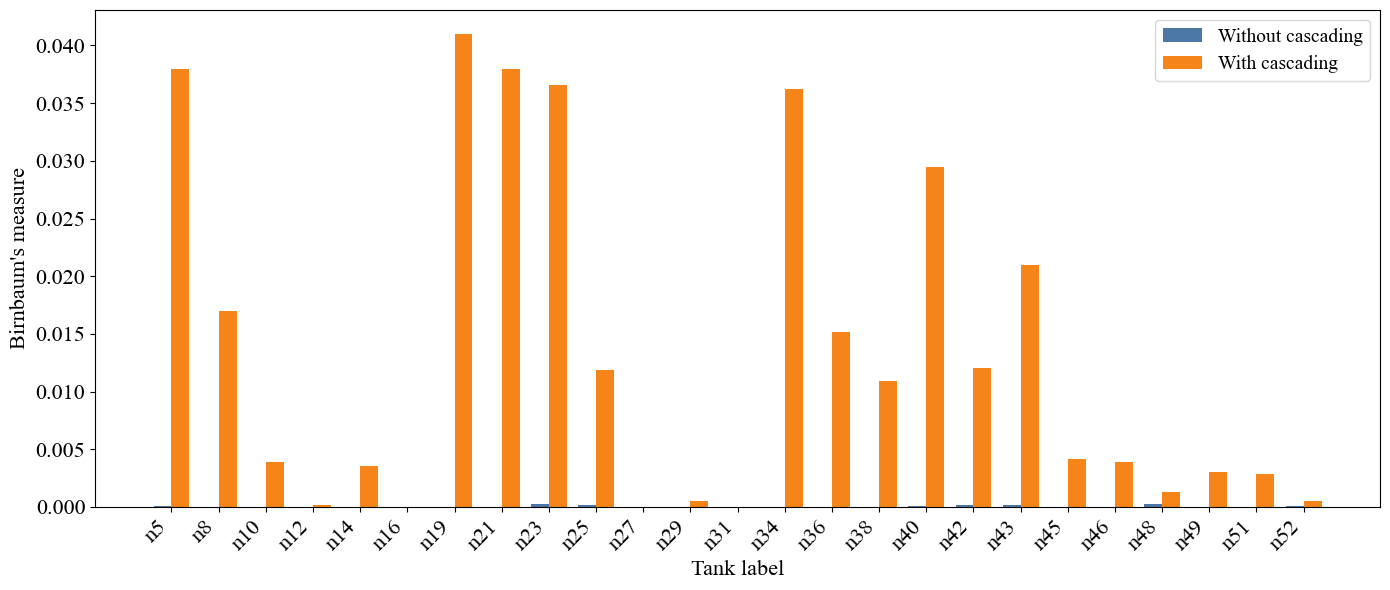

Compared 25 tank nodes between rsr_res and rsr_res_cascading.


In [28]:
cascading_bm_dict = json.loads((Path("rsr_res_cascading") / "bms.json").read_text(encoding="utf-8"))
base_bm_dict = json.loads((Path("rsr_res") / "bms.json").read_text(encoding="utf-8"))

tank_records = [
    (tank_label, comp_id)
    for tank_label, comp_id in zip(TANK_NODES, tank_comp_ids)
    if comp_id in base_bm_dict and comp_id in cascading_bm_dict
]

tank_labels = [tank_label for tank_label, _ in tank_records]
tank_bms_base = [base_bm_dict[comp_id] for _, comp_id in tank_records]
tank_bms_cascading = [cascading_bm_dict[comp_id] for _, comp_id in tank_records]

FIGPATH = Path("figs")
FIGPATH.mkdir(parents=True, exist_ok=True)

FONT_FAMILY = "Times New Roman"
LABEL_SIZE = 16
TICK_SIZE = 16

x = np.arange(len(tank_labels))
width = 0.38

mpl.rcParams["font.family"] = FONT_FAMILY
plt.figure(figsize=(14, 6))
plt.bar(x - width / 2, tank_bms_base, width=width, label="Without cascading", color="#4C78A8")
plt.bar(x + width / 2, tank_bms_cascading, width=width, label="With cascading", color="#F58518")
plt.xlabel("Tank label", fontsize=LABEL_SIZE)
plt.ylabel("Birnbaum's measure", fontsize=LABEL_SIZE)
plt.xticks(x, tank_labels, rotation=45, ha="right", fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)
plt.legend(fontsize=LABEL_SIZE - 2)
plt.tight_layout()
plt.savefig(FIGPATH / "bm_tank_bar_compare.png", dpi=300)
plt.show()

print(f"Compared {len(tank_labels)} tank nodes between rsr_res and rsr_res_cascading.")